# Indian F&O Pair-Trading — Analysis Notebook

End-to-end walkthrough of the statistical pair-trading pipeline: universe →
data → clean → correlation → cointegration (3 windows) + ADF → hedge ratio →
z-score signals → backtest.

All heavy computation lives in the `pairtrading` package and `run_pipeline.py`;
this notebook **loads the produced artefacts** and visualises them.  If the
`data/` CSVs are missing, run `python run_pipeline.py` first.

In [1]:
# --- setup: make the project importable and point at the artefacts ---------- #
import os, sys
from pathlib import Path

# locate the project root (this notebook lives in notebooks/)
ROOT = Path.cwd()
if (ROOT / "notebooks").exists() and (ROOT / "config.py").exists():
    pass
elif (ROOT.parent / "config.py").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import CFG, FILES
from pairtrading.returns import load_clean_matrix, compute_returns
from pairtrading.signals import compute_spread, zscore, generate_positions

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
print("Project root:", ROOT)
print("History window:", CFG.start_date, "->", CFG.end_date)

Project root: c:\Users\Arjun Premkumar\Documents\Arjun Summer 26\Certifications\AMD AI Certification\pair-trading
History window: 2022-07-05 -> 2026-07-05


## 1. Universe & data

In [2]:
universe = pd.read_csv(FILES["universe"])
clean = load_clean_matrix(FILES["clean"])
print(f"F&O universe selected : {len(universe)} symbols")
print(f"Clean price matrix     : {clean.shape[0]} trading days x {clean.shape[1]} symbols")
universe.head(10)

F&O universe selected : 210 symbols
Clean price matrix     : 989 trading days x 198 symbols


,Symbol,CompanyName
0,360ONE,360 One Wam Limited
1,ABB,ABB India Limited
2,ABCAPITAL,Aditya Birla Capital Limited
3,ADANIENSOL,Adani Energy Solutions Limited
4,ADANIENT,Adani Enterprises Limited
5,ADANIGREEN,Adani Green Energy Limited
6,ADANIPORTS,Adani Ports and Special Economic Zone Limited
7,ADANIPOWER,Adani Power Limited
8,ALKEM,Alkem Laboratories Limited
9,AMBER,Amber Enterprises India Limited


## 2. The selection funnel
How the ~20k candidate pairs are filtered down.

,pairs
All pairs (NC2),19503
Correlation >= 0.70,22
Cointegrated (gate=1yr),1
ADF-stationary + selected,1


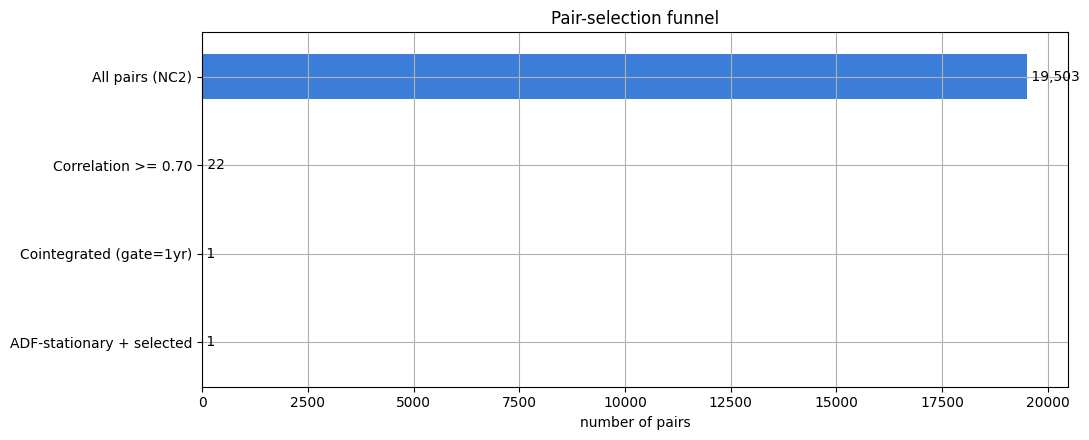

In [3]:
counts = {
    "All pairs (NC2)":        len(pd.read_csv(FILES["all_pairs"])),
    "Correlation >= %.2f" % CFG.corr_threshold: len(pd.read_csv(FILES["correlated"])),
    "Cointegrated (gate=%s)" % "+".join(CFG.coint_gate_windows): len(pd.read_csv(FILES["cointegrated"])),
    "ADF-stationary + selected": len(pd.read_csv(FILES["selected"])),
}
funnel = pd.Series(counts)
display(funnel.to_frame("pairs"))

ax = funnel.plot(kind="barh", color="#3b7dd8")
ax.invert_yaxis(); ax.set_title("Pair-selection funnel"); ax.set_xlabel("number of pairs")
for i, v in enumerate(funnel.values):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout(); plt.show()

## 3. Correlation survivors
Daily-return Pearson correlation (never on raw prices).

In [4]:
corr = pd.read_csv(FILES["correlated"])
print(f"{len(corr)} pairs with return-correlation >= {CFG.corr_threshold}")
corr.head(15)

22 pairs with return-correlation >= 0.7


,Stock1,Stock2,Correlation
0,PFC,RECLTD,0.901139
1,BPCL,HINDPETRO,0.838041
2,BPCL,IOC,0.817503
3,BANKBARODA,CANBK,0.806244
4,CANBK,PNB,0.787355
5,HINDPETRO,IOC,0.783489
6,BAJAJFINSV,BAJFINANCE,0.778279
7,ADANIENT,ADANIPORTS,0.769003
8,ADANIENSOL,ADANIGREEN,0.759334
9,SAIL,TATASTEEL,0.747520


## 4. Cointegration & ADF diagnostics

In [5]:
coint = pd.read_csv(FILES["cointegrated"])
adf = pd.read_csv(FILES["adf"])
print("Cointegrated (gate passed) — 120d/60d flags shown as robustness diagnostics:")
display(coint)
print("ADF test on the spread (needs p < %.2f for stationarity):" % CFG.adf_pvalue)
display(adf)

Cointegrated (gate passed) — 120d/60d flags shown as robustness diagnostics:


,Stock1,Stock2,Cointegration_1yr,Cointegration_120d,Cointegration_60d
0,BANKBARODA,CANBK,True,False,False


ADF test on the spread (needs p < 0.05 for stationarity):


,Stock1,Stock2,ADF_statistic,ADF_pvalue
0,BANKBARODA,CANBK,-3.858655,0.002361


## 5. Deep-dive on the selected pair(s)
For each finally-selected pair we visualise: normalised prices, the return
scatter, the spread with its rolling mean, the z-score with entry/exit bands,
and the price-ratio vs its 30/60/150/200-day moving averages (per the strategy
worksheet).

,Stock1,Stock2,ADF_pvalue,Correlation,Alpha,Beta,HalfLife,Beta_h
0,BANKBARODA,CANBK,0.002361,0.806244,71.582088,1.544044,22.894982,1.544044


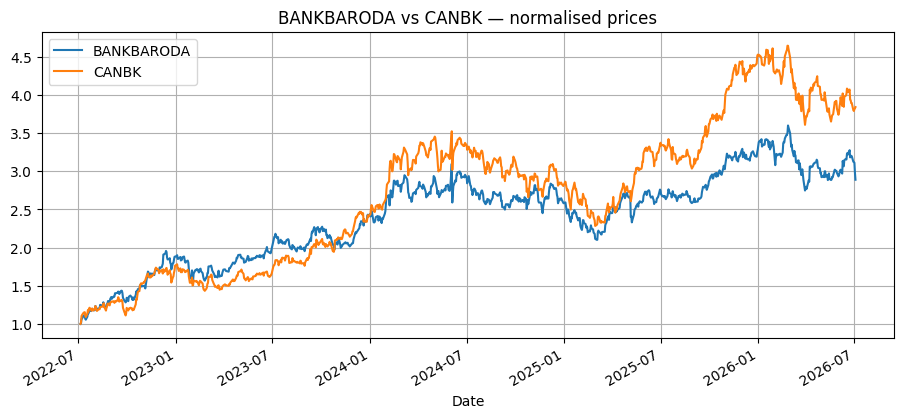

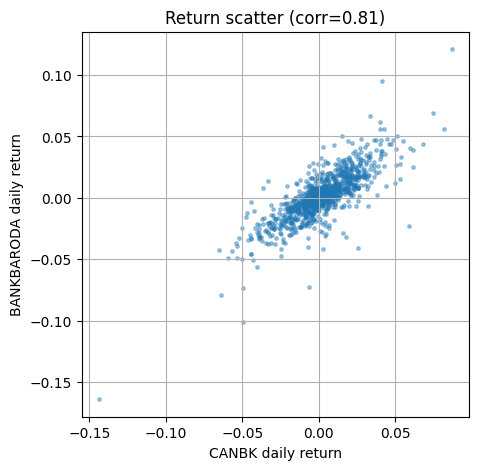

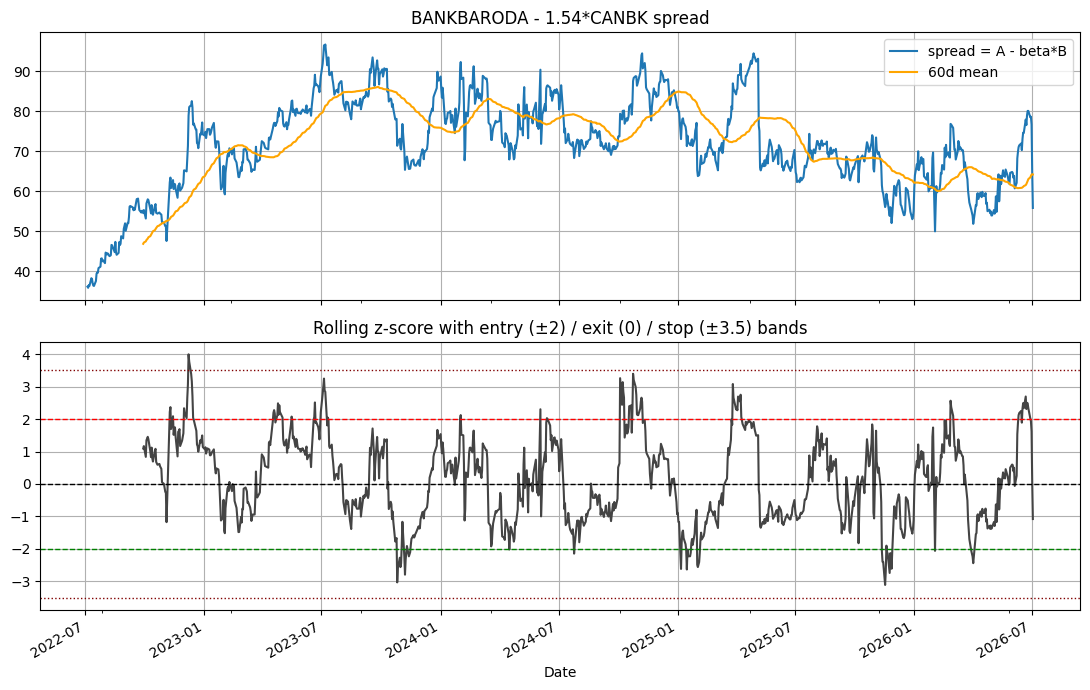

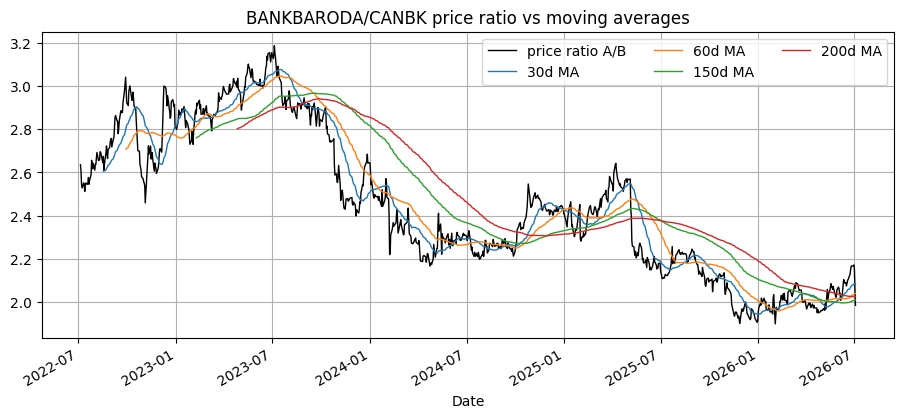

In [6]:
selected = pd.read_csv(FILES["selected"])
hedge = pd.read_csv(FILES["hedge"])
selected = selected.merge(hedge[["Stock1","Stock2","Beta"]], on=["Stock1","Stock2"],
                          how="left", suffixes=("", "_h"))
if "Beta" not in selected.columns:
    selected["Beta"] = selected["Beta_h"]
display(selected)

def analyse_pair(a, b, beta):
    px = clean[[a, b]].dropna()
    A, B = px[a], px[b]

    # 5a. normalised price levels
    fig, ax = plt.subplots()
    (A/A.iloc[0]).plot(ax=ax, label=a)
    (B/B.iloc[0]).plot(ax=ax, label=b)
    ax.set_title(f"{a} vs {b} — normalised prices"); ax.legend(); plt.show()

    # 5b. daily-return scatter
    r = compute_returns(px)
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(r[b], r[a], s=6, alpha=0.4)
    ax.set_xlabel(f"{b} daily return"); ax.set_ylabel(f"{a} daily return")
    ax.set_title(f"Return scatter (corr={r[a].corr(r[b]):.2f})"); plt.show()

    # 5c. spread + rolling mean, and 5d. z-score with bands
    spread = compute_spread(A, B, beta)
    zf = zscore(spread, CFG.zscore_window)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    zf["Spread"].plot(ax=ax1, label="spread = A - beta*B")
    zf["RollingMean"].plot(ax=ax1, label=f"{CFG.zscore_window}d mean", color="orange")
    ax1.set_title(f"{a} - {beta:.2f}*{b} spread"); ax1.legend()
    zf["Z"].plot(ax=ax2, color="#444")
    for lvl, c in [(CFG.z_entry,"r"), (-CFG.z_entry,"g"), (0,"k")]:
        ax2.axhline(lvl, color=c, ls="--", lw=1)
    ax2.axhline(CFG.z_stop, color="maroon", ls=":", lw=1)
    ax2.axhline(-CFG.z_stop, color="maroon", ls=":", lw=1)
    ax2.set_title("Rolling z-score with entry (±2) / exit (0) / stop (±3.5) bands")
    plt.tight_layout(); plt.show()

    # 5e. price ratio vs 30/60/150/200-day MAs (strategy-worksheet request)
    ratio = A / B
    fig, ax = plt.subplots()
    ratio.plot(ax=ax, label="price ratio A/B", color="black", lw=1)
    for w in (30, 60, 150, 200):
        ratio.rolling(w).mean().plot(ax=ax, label=f"{w}d MA", lw=1)
    ax.set_title(f"{a}/{b} price ratio vs moving averages"); ax.legend(ncol=3); plt.show()

for r in selected.itertuples(index=False):
    if pd.notna(getattr(r, "Beta", np.nan)):
        analyse_pair(r.Stock1, r.Stock2, float(r.Beta))

## 6. Backtest — equity curve, drawdown & trades

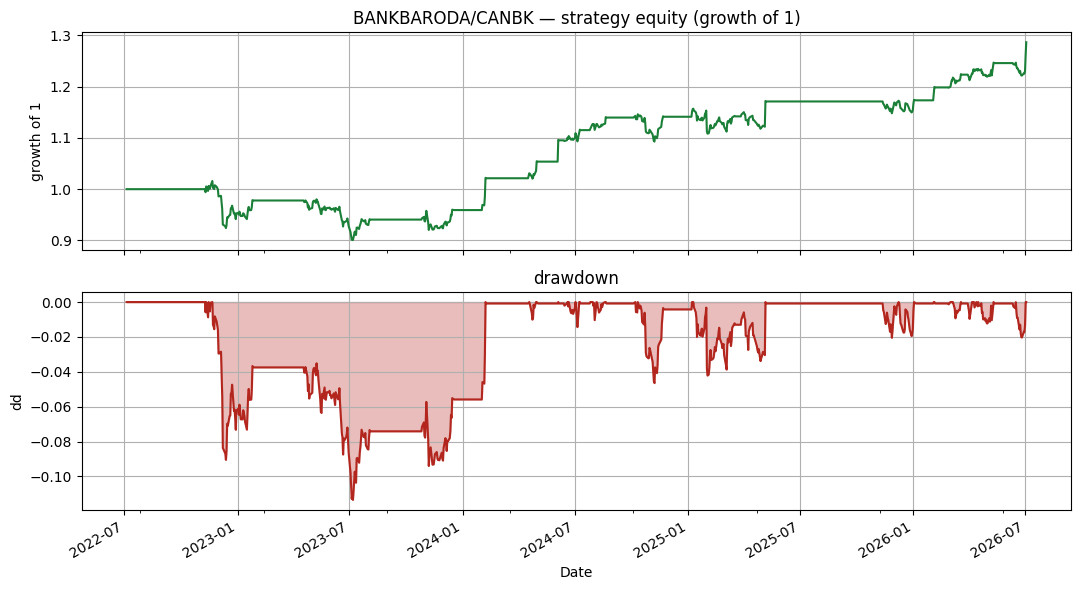

In [7]:
def backtest_curve(a, b, beta):
    px = clean[[a, b]].dropna(); A, B = px[a], px[b]
    spread = compute_spread(A, B, beta)
    zf = zscore(spread, CFG.zscore_window)
    pos = generate_positions(zf["Z"]).shift(1).fillna(0.0)   # act next bar
    dA, dB = A.diff(), B.diff()
    gross = A.shift(1).abs() + abs(beta)*B.shift(1).abs()
    ret = pos*(dA - beta*dB)/gross.replace(0, np.nan)
    cost = pos.diff().abs().fillna(pos.abs())*2*(CFG.txn_cost_bps/1e4)
    net = (ret-cost).fillna(0.0)
    equity = (1+net).cumprod()
    dd = equity/equity.cummax()-1
    fig, (a1,a2) = plt.subplots(2,1, figsize=(11,6), sharex=True)
    equity.plot(ax=a1, color="#1a7f37"); a1.set_title(f"{a}/{b} — strategy equity (growth of 1)")
    a1.set_ylabel("growth of 1")
    dd.plot(ax=a2, color="#b3261e"); a2.fill_between(dd.index, dd.values, color="#b3261e", alpha=0.3)
    a2.set_title("drawdown"); a2.set_ylabel("dd")
    plt.tight_layout(); plt.show()

for r in selected.itertuples(index=False):
    if pd.notna(getattr(r, "Beta", np.nan)):
        backtest_curve(r.Stock1, r.Stock2, float(r.Beta))

In [8]:
print("Per-pair backtest summary:")
display(pd.read_csv(FILES["backtest"]))
print("\nTrade log:")
display(pd.read_csv(FILES["signals"]))

Per-pair backtest summary:


,Stock1,Stock2,Beta,TotalReturnPct,AnnReturnPct,Sharpe,MaxDrawdownPct,NumTrades,WinRatePct,AvgTradeRetPct,AvgHoldingDays,MinHoldingDays,MaxHoldingDays
0,BANKBARODA,CANBK,1.544,28.6656,6.7201,0.8693,-11.3421,17,88.24,1.6172,24.1,1,75



Trade log:


,Stock1,Stock2,Direction,EntryDate,ExitDate,HoldingDays,EntryZ,ExitZ,TradeReturnPct
0,BANKBARODA,CANBK,SHORT_SPREAD,2022-11-10,2022-12-08,21,2.366863,3.993561,-6.9081
1,BANKBARODA,CANBK,SHORT_SPREAD,2022-12-12,2023-01-25,33,3.388997,-0.204707,5.2136
2,BANKBARODA,CANBK,SHORT_SPREAD,2023-04-19,2023-08-03,75,2.274839,-0.095613,-3.7297
3,BANKBARODA,CANBK,LONG_SPREAD,2023-10-27,2023-12-15,34,-2.590571,0.195063,2.0538
4,BANKBARODA,CANBK,SHORT_SPREAD,2024-02-02,2024-02-07,4,1.517024,-1.124750,6.5592
5,BANKBARODA,CANBK,LONG_SPREAD,2024-04-18,2024-04-30,9,-1.317378,0.323591,3.2560
6,BANKBARODA,CANBK,SHORT_SPREAD,2024-06-04,2024-06-04,1,-0.997377,-0.997377,4.0278
7,BANKBARODA,CANBK,SHORT_SPREAD,2024-06-14,2024-07-09,17,2.006352,-0.221634,1.8977
8,BANKBARODA,CANBK,LONG_SPREAD,2024-07-26,2024-08-20,17,-1.848890,0.012773,2.2801
9,BANKBARODA,CANBK,SHORT_SPREAD,2024-10-07,2024-11-21,32,2.438332,-0.142878,0.2175


## 7. Notes & next steps
- Selection is intentionally strict (correlation ≥ 0.70 on returns, 1-year
  Engle-Granger cointegration gate + ADF stationarity), so few pairs survive —
  this is the honest result on live 2022–2026 data, not a bug.
- To widen the tradable set, lower `CFG.corr_threshold` (e.g. 0.60) or relax the
  cointegration gate in `config.py`, then rerun `python run_pipeline.py --force`.
- Follow-ups flagged in the strategy worksheet: walk-forward optimisation and
  ranking by drawdown / time-to-revert (half-life and drawdown columns already
  support the latter).